In [1]:
import matplotlib.pyplot as plt
import numpy as np
import graph_style as gs
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
import fig_helper as fh

gs.set_graph_style(1.0)



In [2]:

def gaussian_func(x, a, sigma):
    return a * np.exp(-((x) ** 2) / (sigma**2))


def exp_func(x, a, sigma):
    return a * np.exp(-(x) / (sigma))



In [3]:

date = "2025-06-05"
rid_dict = {36415: "FNC", 36419: "No FNC"}


Text(-0.1, 1.0, 'a')

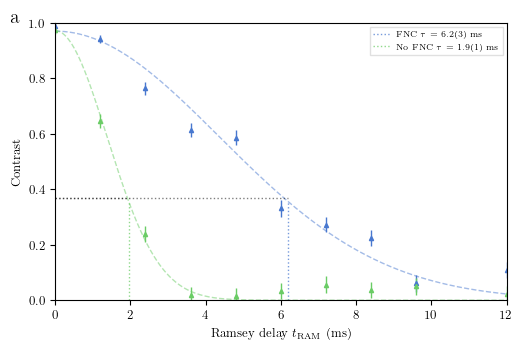

In [4]:

fig = plt.figure()
for rid in rid_dict.keys():
    dict = fh.load_data(rid, date)
    delays = (
        np.array(dict["datasets"][f"ndscan.rid_{rid}.points.axis_0"]) * 1e3
    )  # convert to us
    contrast = np.array(
        dict["datasets"][f"ndscan.rid_{rid}.points.channel_scan_ion_phase_contrast"]
    )
    contrast_err = np.array(
        dict["datasets"][f"ndscan.rid_{rid}.points.channel_scan_ion_phase_contrast_err"]
    )
    argsort = np.argsort(delays)
    # remove second last point, which is a large outlier
    argsort = np.delete(argsort, -2)
    delays = delays[argsort]
    contrast = contrast[argsort]
    contrast_err = contrast_err[argsort]

    # ----------- gauss func
    initial_guess = [1, 2]

    popt_ramsey, pcov_ramsey = curve_fit(
        gaussian_func, delays, contrast, sigma=contrast_err, p0=initial_guess
    )
    p_err = np.sqrt(np.diag(pcov_ramsey))

    xplot = np.linspace(0, np.max(delays), 1000)
    num = rid % 3 - 1
    c = gs.get_color(num)
    plt.errorbar(delays, contrast, yerr=contrast_err, fmt="^", color=c, elinewidth=1.0)
    plt.plot(xplot, gaussian_func(xplot, *popt_ramsey), color=c, alpha=0.5)
    # add v line at coherence time, that goes to height of the fit
    height = gaussian_func(popt_ramsey[1], *popt_ramsey)
    plt.vlines(
        popt_ramsey[1],
        0,
        height,
        color=c,
        linestyle=":",
        label=f"{rid_dict[rid]} $\\tau$ = {popt_ramsey[1]:.1f}({p_err[1]*10:.0f}) ms",
        alpha=0.75,
    )
    # horizontal line at 1/e that ends at the fit line

    plt.hlines(
        1 / np.e,
        0,
        popt_ramsey[1],
        color="black",
        linestyle=":",
        alpha=0.5,
    )


plt.ylabel("Contrast")
plt.xlabel("Ramsey delay $t_{\\rm RAM}$ (ms)")
plt.xlim(0, np.max(delays))
plt.ylim(0, 1)
plt.grid()
plt.legend()
# label figure text "a" in the top left corner
plt.text(
    -0.10,
    1.0,
    "a",
    transform=plt.gca().transAxes,
    fontsize=14,
    fontweight="bold",
)
# plt.savefig("fnc_coherence.pdf")


In [ ]:

# ----------------------
""" repeat for mag field"""

date = "2025-06-05"
rid_dict = {36418: "+3/2", 36412: "-5/2", 36415: "-3/2"}

fig, ax1 = plt.subplots()

# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.65, 0.45, 0.25, 0.2]
ax2 = fig.add_axes([left, bottom, width, height])


for rid in rid_dict.keys():
    dict = fh.load_data(rid, date)
    delays = (
        np.array(dict["datasets"][f"ndscan.rid_{rid}.points.axis_0"]) * 1e3
    )  # convert to us
    contrast = np.array(
        dict["datasets"][f"ndscan.rid_{rid}.points.channel_scan_ion_phase_contrast"]
    )
    contrast_err = np.array(
        dict["datasets"][f"ndscan.rid_{rid}.points.channel_scan_ion_phase_contrast_err"]
    )
    argsort = np.argsort(delays)
    if rid == 36412:
        argsort = np.delete(argsort, 1)
    elif rid == 36415:
        argsort = np.delete(argsort, -2)
    delays = delays[argsort]
    contrast = contrast[argsort]
    contrast_err = contrast_err[argsort]

    # ----------- gauss func
    initial_guess = [1, 2]

    popt_ramsey, pcov_ramsey = curve_fit(
        gaussian_func, delays, contrast, sigma=contrast_err, p0=initial_guess
    )
    p_err = np.sqrt(np.diag(pcov_ramsey))

    xplot = np.linspace(0, np.max(delays), 1000)
    num = (rid - 3) % 4
    c = gs.get_color(num)
    ax1.errorbar(delays, contrast, yerr=contrast_err, fmt="^", color=c, elinewidth=1.0)
    ax1.plot(xplot, gaussian_func(xplot, *popt_ramsey), color=c, alpha=0.5)
    # add v line at coherence time, that goes to height of the fit
    height = gaussian_func(popt_ramsey[1], *popt_ramsey)
    ax1.vlines(
        popt_ramsey[1],
        0,
        height,
        color=c,
        linestyle=":",
        label=r"$|3D_{5/2},~m_j =$ "
        + f"{rid_dict[rid]}$\\rangle$ $\\tau$ = {popt_ramsey[1]:.1f}({p_err[1]*10:.0f}) ms",
        alpha=0.75,
    )
    # horizontal line at 1/e that ends at the fit line

    ax1.hlines(
        1 / np.e,
        0,
        popt_ramsey[1],
        color="black",
        linestyle=":",
        alpha=0.5,
    )


ax1.set_ylabel("Contrast")
ax1.set_xlabel("Ramsey delay $t_{\\rm RAM}$ (ms)")
ax1.set_xlim(0, np.max(delays) + 2)
ax1.set_ylim(0, 1)
ax1.grid()
ax1.legend()

# -------
"""
Plot coherence time vs magnetic field sensitivity
"""
mag_sens = [+0.624, -0.446, -0.178]
mag_sens = np.abs(mag_sens)

coherence_times = [1.568, 2.257, 6.179]
coherence_times_err = [0.166, 0.301, 0.298]

c = "black"
ax2.errorbar(
    mag_sens,
    coherence_times,
    yerr=coherence_times_err,
    fmt="^",
    color=c,
    elinewidth=1.0,
)


# linear fit
def linear_fit(x, a, b):
    return a * x + b


p_fit, p_cov = curve_fit(
    linear_fit,
    mag_sens,
    coherence_times,
    sigma=coherence_times_err,
    p0=[-1, 10],
)
p_err = np.sqrt(np.diag(p_cov))
ax2.plot(
    mag_sens,
    linear_fit(mag_sens, *p_fit),
    color=c,
    alpha=0.75,
)

ax2.set_xlabel("B-field sensitivity (MHz/G)", fontsize=9)
ax2.set_ylabel("$\\tau$ (ms)", fontsize=9)
ax1.text(
    -0.10,
    0.98,
    "b",
    transform=ax1.transAxes,
    fontsize=14,
    fontweight="bold",
)
# plt.savefig("mag_coherence.pdf")

In [131]:
## RPE analysis
 
from scipy.signal import welch

def gaussian_func(x, a, sigma):
    return a * np.exp(-((x) ** 2) / (sigma**2))

def exp_func(x, a, sigma):
    return a * np.exp(-(x) / (sigma))

def exp_sin_func(x, a, sigma, f, phi, a_s):
    A = a + a_s*np.sin(2 * np.pi * f * x + phi)
    return A * np.exp(-(x) / (sigma))

def load_data(rid, day):
    result = fh.load_result(rid=rid, day=day, experiment="fastgates")
    print(result["datasets"].keys())
    A = result["datasets"][f"ndscan.rid_{rid}.analysis_result.ion_phase_contrast"]
    A_err = result["datasets"][f"ndscan.rid_{rid}.analysis_result.ion_phase_contrast_err"]
    b = np.array(result["datasets"][f"ndscan.rid_{rid}.points.axis_1"])*1000 # in ms
    return b, A, A_err


def load_freq_servo_data(rid, day):
    result = fh.load_result(rid=rid, day=day, experiment="fastgates")
    # print(result.keys())
    # print(result["archive"].keys())
    ds = result["datasets"]
    transitions = ["m1_m3", "m1_m5", "m1_p3"]
    A_arr = np.array([])
    A_err_arr = np.array([])
    delays_arr = np.array([])
    c_arr = np.array([])

   

    for t in transitions:
        coherence_time = result["archive"][f"gates.simple_729.{t}.coherence_time"]
        A = ds[f"gates.simple_729.{t}.rpe_frequency_servo.analysis_result.contrasts_1"]
        A_err = ds[f"gates.simple_729.{t}.rpe_frequency_servo.analysis_result.contrasts_sigmas_1"]
        b = np.array(ds[f"gates.simple_729.{t}.rpe_frequency_servo.points.axis_0"]) # in ms
        c = np.array(ds[f"gates.simple_729.{t}.rpe_frequency_servo.analysis_result.coherence_times_1"])
        b = np.unique(b)
        t0 = coherence_time / 2**np.max(b)
        argsort = np.argsort(b)
        b = b[argsort]
        A = A[argsort]
        A = np.clip(A, 0, 1)
        delays = np.array([t0*2**b_i for b_i in b])*1000 # in ms

        A_err = A_err[argsort]
        A_arr = np.append(A_arr, A)
        A_err_arr = np.append(A_err_arr, A_err)
        delays_arr = np.append(delays_arr, delays)
        c_arr = np.append(c_arr, c)
    A_arr = A_arr.reshape(len(transitions), -1)
    A_err_arr = A_err_arr.reshape(len(transitions), -1)
    delays_arr = delays_arr.reshape(len(transitions), -1)
    return delays_arr, A_arr, A_err_arr, c_arr



In [197]:


def plot_data(ax, delays, contrast, contrast_err, popt, osc, freq, psd, i, t):
    c = gs.get_color(i)
    x_fit = np.linspace(np.min(delays), np.max(delays), 1000)
    y_fit = exp_func(x_fit, *popt)
    ax.errorbar(delays, contrast, yerr=contrast_err, fmt="^", color=c)
    ax.plot(x_fit, y_fit, color=c, label=t, ls='-')
    ax.set_xlabel("Delay time (ms)")
    ax.set_ylabel("Contrast")
    # ft.set_xlim(-0.5, 25.5)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([0, 5, 10, 15, 20, 25])
    ax.set_yticks([0, 0.5, 1])
    ax.legend(frameon=True, loc="lower center")
    ax.grid(None)
    ax.set_xscale("log")
    return axs

def fit_coher(delays, contrast, contrast_err):

    popt, pcov = curve_fit(
        exp_func,
        delays,
        contrast,
        sigma=contrast_err,
        p0=[1, 10],
        bounds=([0.95, 0], [1.0, np.inf])
    )
    p_err = np.sqrt(np.diag(pcov))
    print(f"Coherence time: {popt[1]:.3e} ± {p_err[1]:.3e} s")

    x_fit = np.linspace(np.min(delays), np.max(delays), 1000)
    y_fit = exp_func(x_fit, *popt)

    """ Remove baseline decay from data and fft to see spectrum"""
    osc = contrast - exp_func(delays, *popt)
    osc = osc - np.mean(osc)
    delays_s = delays/1000

    nyquist_freq = 1/(2*(delays_s[1]-delays_s[0])) # in Hz
    # print(f"Nyquist frequency: {nyquist_freq:.2f} Hz")

    fs = 1 / np.mean(np.diff(delays_s))  # Sampling frequency in Hz

    freq, psd = welch(
        osc,
        fs=fs,
        window='hann',
        nperseg=len(osc),
        nfft=2048
    )

    psd = psd / np.max(psd)  # Normalize the PSD
    return freq, psd, popt, p_err

In [172]:

day = "2026-08-14"
rids = [137190, 137200,137220, 137228, 137236, 137242, 137249, 137256, 137263, 137270, 137277]

transitions = ["m1_m3", "m1_m5", "m1_p3"]
for j, rid in enumerate(rids):
    if j == 0:
        t_arr, contrast_arr, contrast_arr_err, coherence_arr = load_freq_servo_data(rid, day)
    else:
        t_arr_j, contrast_arr_j, contrast_arr_err_j, coherence_arr_j = load_freq_servo_data(rid, day)
        t_arr = np.sum(np.array([t_arr, t_arr_j]), axis=0)
        contrast_arr = np.sum(np.array([contrast_arr, contrast_arr_j]), axis=0)
        print(f"{j}: {contrast_arr_j}")
        coherence_arr = np.sum(np.array([coherence_arr, coherence_arr_j]), axis=0)
        contrast_arr_err = np.sqrt(np.sum(np.array([contrast_arr_err**2, contrast_arr_err_j**2]), axis=0))

contrast_arr = contrast_arr / len(rids)
contrast_arr_err = contrast_arr_err / len(rids)
coherence_arr = coherence_arr / len(rids)
t_arr = t_arr / len(rids)




1: [[1.         0.97581874 0.97581874 0.93867519 0.83399973 0.91043335
  0.85440037 0.99442893 0.56666667 0.68718427]
 [1.         0.9545214  0.94280904 0.96724121 0.87496032 0.95510325
  0.73181661 0.7007932  0.12018504 0.66164777]
 [1.         1.         0.96205798 1.         0.85440037 0.85179549
  0.61191866 0.2538591  0.12018504 0.13333333]]
2: [[0.93392838 1.         1.         1.         1.         0.98092926
  0.82462113 0.68718427 0.9067647  0.7490735 ]
 [1.         1.         1.         0.94280904 1.         0.93333333
  0.7363574  0.71802197 0.23570226 0.7       ]
 [1.         0.90246576 1.         0.90061707 0.86666667 0.76955976
  0.31446604 0.35901099 0.12018504 0.58214164]]
3: [[1.         1.         0.93392838 0.98713953 0.94809751 0.90246576
  0.90061707 0.89752747 0.8232726  0.67986927]
 [1.         1.         1.         0.99442893 0.98036274 1.
  0.67494856 0.63683244 0.50881125 0.78669491]
 [1.         0.93392838 0.91530201 0.92975505 0.89690827 0.68718427
  0.43461

Coherence time: 5.950e+01 ± 1.600e+01 s
Coherence time: 1.691e+01 ± 4.203e+00 s
Coherence time: 7.754e+00 ± 1.634e+00 s


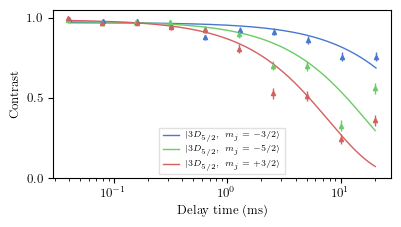

In [202]:
fig_width = gs.get_fig_width()*3/4
fig_height = fig_width * 1/2

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

coherence_times = []
coherence_times_err = []
transition_label =[r"$|3D_{5/2},~m_j = -3/2\rangle$", r"$|3D_{5/2},~m_j = -5/2\rangle$", r"$|3D_{5/2},~m_j = +3/2\rangle$"]
for i, t in enumerate(transitions):
    delays = t_arr[i]
    contrast = contrast_arr[i]
    contrast_err = contrast_arr_err[i]
    freq, psd, popt, p_err = fit_coher(delays, contrast, contrast_err)
    label = transition_label[i]
    axs = plot_data(ax, delays, contrast, contrast_err, popt, contrast - gaussian_func(delays, *popt) - np.mean(contrast - gaussian_func(delays, *popt)), freq, psd, i,label)
    coherence_times.append(popt[1])
    coherence_times_err.append(p_err[1])


f_name = "..\\..\\pdf_figure\\ch4\\spin_coherence_py.pdf"
plt.savefig(f_name, bbox_inches="tight")

Fit parameters: a = 0.027 ± 0.017, b = 0.000 ± 0.046


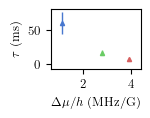

In [207]:
b_sense = np.array([0.178, 0.446, 0.624])*2*np.pi
inv_coherence = np.array([1/c for c in coherence_times])
inv_coherence_err = np.array([c_err/c**2 for c, c_err in zip(coherence_times, coherence_times_err)])

def linear_fit(x, a, b):
    return a * x + b

def inv_prop(x, a, b):
    return 1/(a*x+b)

popt, p_cov = curve_fit(
    inv_prop,
    b_sense,
    coherence_times,
    sigma=coherence_times_err,
    p0=[1, 0],
    bounds=([0, 0], [np.inf, np.inf])
)
p_err = np.sqrt(np.diag(p_cov))
print(f"Fit parameters: a = {popt[0]:.3f} ± {p_err[0]:.3f}, b = {popt[1]:.3f} ± {p_err[1]:.3f}")

x_fit = np.linspace(np.min(b_sense), np.max(b_sense), 1000)
y_fit = inv_prop(x_fit, *popt)

fig_width = gs.get_fig_width()*1/5
fig_height = fig_width *2/3
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
for i, t in enumerate(transitions):
    c = gs.get_color(i)
    ax.errorbar(
        b_sense[i],
        coherence_times[i],
        yerr=coherence_times_err[i],
        fmt="^",
        color=c,
        elinewidth=1.0,
        label=t
    )
plt.xlim(np.min(b_sense)-0.5, np.max(b_sense)+0.5)
plt.ylim(np.min(coherence_times)-15, np.max(coherence_times)+20)
# plt.plot(x_fit, y_fit, color="k", alpha=0.75, ls='-')
plt.xlabel("$\\Delta\\mu/h$ (MHz/G)")
plt.ylabel("$\\tau$ (ms)")
plt.grid(None)
f_name = "..\\..\\pdf_figure\\ch4\\coherence_vs_b_sense.pdf"
# make transparenet
plt.savefig(f_name, bbox_inches="tight", transparent=True)